# DSMarket - creaccion modelo

## 1. Importing libraries

In [5]:

from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings("ignore")
import os
from google.colab import files

import numpy as np
import pandas as pd

import gc
import os
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split # Added this import

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit

from prophet import Prophet

pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

Mounted at /content/drive


cargar sataset original

---


---

In [6]:
output_path = "/content/drive/MyDrive/Master/TFM/item_sales_weekly_result.csv"

In [7]:

df = pd.read_csv(output_path)


In [8]:
df.head()

,yearweek,region,category,store_code,item,id,Total_Sales_Weekly,event,sell_price
0,201105,New York,ACCESORIES,NYC_1,ACCESORIES_1_001,ACCESORIES_1_001_NYC_1,0,NaN,NaN
1,201105,New York,ACCESORIES,NYC_1,ACCESORIES_1_002,ACCESORIES_1_002_NYC_1,0,NaN,NaN
2,201105,New York,ACCESORIES,NYC_1,ACCESORIES_1_003,ACCESORIES_1_003_NYC_1,0,NaN,NaN
3,201105,New York,ACCESORIES,NYC_1,ACCESORIES_1_004,ACCESORIES_1_004_NYC_1,0,NaN,NaN
4,201105,New York,ACCESORIES,NYC_1,ACCESORIES_1_005,ACCESORIES_1_005_NYC_1,0,NaN,NaN


cargar dataset para modeling

In [9]:
df= pd.read_csv("/content/drive/MyDrive/Master/TFM/df_feature_encod.csv")

In [10]:
df

,date,yearweek,store_code,item,id,sales,sell_price,year,week,revenue,revenue_log,sales_log,sales_avg_by_week_historical,sales_avg_by_week_store_category,sales_same_week_last_year,sales_ratio_vs_last_year,seasonal_index,sales_yearly_trend,sales_deviation_from_yearly_trend,store_code_category_sales_sum_W_SAT_shift_1,store_code_category_sales_sum_W_SAT_shift_2,store_code_category_sales_sum_W_SAT_shift_4,store_code_category_sales_sum_W_SAT_shift_7,store_code_category_sales_sum_W_SAT_ma_3,store_code_category_sales_sum_W_SAT_ma_7,store_code_category_sales_sum_W_SAT_ma_14,store_code_category_sales_sum_W_SAT_trend_7,store_code_category_sales_sum_W_SAT_std_7,store_code_category_sales_sum_W_SAT_cv_7,store_code_category_sales_sum_W_SAT_ratio_shift_1,store_code_category_sales_sum_W_SAT_momentum_7,store_code_category_revenue_sum_W_SAT_shift_1,store_code_category_revenue_sum_W_SAT_shift_2,store_code_category_revenue_sum_W_SAT_shift_4,store_code_category_revenue_sum_W_SAT_shift_7,store_code_category_revenue_sum_W_SAT_ma_3,store_code_category_revenue_sum_W_SAT_ma_7,store_code_category_revenue_sum_W_SAT_ma_14,store_code_category_revenue_sum_W_SAT_trend_7,store_code_category_revenue_sum_W_SAT_std_7,store_code_category_revenue_sum_W_SAT_cv_7,store_code_category_revenue_sum_W_SAT_ratio_shift_1,store_code_category_revenue_sum_W_SAT_momentum_7,store_code_item_sales_sum_W_SAT_shift_1,store_code_item_sales_sum_W_SAT_shift_2,store_code_item_sales_sum_W_SAT_shift_4,store_code_item_sales_sum_W_SAT_shift_7,store_code_item_sales_sum_W_SAT_ma_3,store_code_item_sales_sum_W_SAT_ma_7,store_code_item_sales_sum_W_SAT_ma_14,store_code_item_sales_sum_W_SAT_trend_7,store_code_item_sales_sum_W_SAT_std_7,store_code_item_sales_sum_W_SAT_cv_7,store_code_item_sales_sum_W_SAT_ratio_shift_1,store_code_item_sales_sum_W_SAT_momentum_7,week_sin,week_cos,month,month_sin,month_cos,region_Boston,region_New York,region_Philadelphia,category_ACCESORIES,category_HOME_&_GARDEN,category_SUPERMARKET,event_Easter,event_NewYear,event_None,event_Ramadan starts,event_SuperBowl,event_Thanksgiving,store_code_encoded,id_encoded,item_encoded
0,2014-03-15,201412,BOS_2,ACCESORIES_1_208,ACCESORIES_1_208_BOS_2,0,4.31,2014,12,0.00,0.00,0.00,0.00,0.00,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.99,0.12,3,1.00,0.00,True,False,False,True,False,False,False,False,True,False,False,False,1,2.09,3.25
1,2014-03-15,201412,BOS_2,ACCESORIES_1_248,ACCESORIES_1_248_BOS_2,1,1.25,2014,12,1.25,0.22,0.00,1.00,0.50,NaN,NaN,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.99,0.12,3,1.00,0.00,True,False,False,True,False,False,False,False,True,False,False,False,1,7.92,10.20
2,2014-03-15,201412,BOS_2,ACCESORIES_1_119,ACCESORIES_1_119_BOS_2,1,2.17,2014,12,2.17,0.77,0.00,1.00,0.67,NaN,NaN,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.99,0.12,3,1.00,0.00,True,False,False,True,False,False,False,False,True,False,False,False,1,4.42,4.10
3,2014-03-15,201412,BOS_2,ACCESORIES_1_120,ACCESORIES_1_120_BOS_2,0,13.09,2014,12,0.00,0.00,0.00,0.00,0.50,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.99,0.12,3,1.00,0.00,True,False,False,True,False,False,False,False,True,False,False,False,1,1.45,1.94
4,2014-03-15,201412,BOS_2,ACCESORIES_1_121,ACCESORIES_1_121_BOS_2,0,1.33,2014,12,0.00,0.00,0.00,0.00,0.40,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.99,0.12,3,1.00,0.00,True,False,False,True,False,False,False,False,True,False,False,False,1,1.53,2.9

In [11]:
df["date"]=df["date"].astype("datetime64[ns]")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3323410 entries, 0 to 3323409
Data columns (total 75 columns):
 #   Column                                               Dtype         
---  ------                                               -----         
 0   date                                                 datetime64[ns]
 1   yearweek                                             int64         
 2   store_code                                           object        
 3   item                                                 object        
 4   id                                                   object        
 5   sales                                                int64         
 6   sell_price                                           float64       
 7   year                                                 int64         
 8   week                                                 int64         
 9   revenue                                              float64       
 10  revenu

Creaccion de los dataset para el modelo

In [13]:
target_to_exc= ["sales_log", "sales","revenue","revenue_log"]

In [14]:
cat_cols = []

for col in df.columns:
    if df[col].dtype == 'category' or df[col].dtype == 'object':
        cat_cols.append(col)

print("Columnas dtype object:", cat_cols)

Columnas dtype object: ['store_code', 'item', 'id']


In [15]:
all_dates = sorted(df["date"].unique())

In [16]:
max(df["date"])

Timestamp('2016-04-16 00:00:00')

In [17]:
df["date"].unique()

<DatetimeArray>
['2014-03-15 00:00:00', '2014-03-22 00:00:00', '2014-03-29 00:00:00',
 '2014-04-05 00:00:00', '2014-04-12 00:00:00', '2014-04-19 00:00:00',
 '2014-04-26 00:00:00', '2014-05-03 00:00:00', '2014-05-10 00:00:00',
 '2014-05-17 00:00:00',
 ...
 '2016-02-13 00:00:00', '2016-02-20 00:00:00', '2016-02-27 00:00:00',
 '2016-03-05 00:00:00', '2016-03-12 00:00:00', '2016-03-19 00:00:00',
 '2016-03-26 00:00:00', '2016-04-02 00:00:00', '2016-04-09 00:00:00',
 '2016-04-16 00:00:00']
Length: 109, dtype: datetime64[ns]

In [18]:
min(df["date"])

Timestamp('2014-03-15 00:00:00')

In [19]:
train_dates = all_dates[:-50]
test_dates = all_dates[-50:-15]
validation_dates = all_dates[-15:-4]
prediction_dates = all_dates[-4:]

Creaccion del split para entrenar el modelo y sacar predicciones

In [20]:
def get_data_splits(df, split_dates):
    X_ = (
        df[df["date"].isin(split_dates)]
        .drop(
         ['date'] + cat_cols + target_to_exc, axis = 1)
    .set_index("id_encoded"))


    y_ = df[df["date"].isin(split_dates)].set_index("id_encoded")["sales"]

    print(split_dates)
    print(X_.shape, y_.shape)

    return X_, y_

X_train, y_train = get_data_splits(df=df, split_dates=train_dates)
X_test, y_test = get_data_splits(df=df, split_dates=test_dates)
X_val, y_val = get_data_splits(df=df, split_dates=validation_dates)
X_pred, y_pred = get_data_splits(df=df, split_dates=prediction_dates)

[Timestamp('2014-03-15 00:00:00'), Timestamp('2014-03-22 00:00:00'), Timestamp('2014-03-29 00:00:00'), Timestamp('2014-04-05 00:00:00'), Timestamp('2014-04-12 00:00:00'), Timestamp('2014-04-19 00:00:00'), Timestamp('2014-04-26 00:00:00'), Timestamp('2014-05-03 00:00:00'), Timestamp('2014-05-10 00:00:00'), Timestamp('2014-05-17 00:00:00'), Timestamp('2014-05-24 00:00:00'), Timestamp('2014-05-31 00:00:00'), Timestamp('2014-06-07 00:00:00'), Timestamp('2014-06-14 00:00:00'), Timestamp('2014-06-21 00:00:00'), Timestamp('2014-06-28 00:00:00'), Timestamp('2014-07-05 00:00:00'), Timestamp('2014-07-12 00:00:00'), Timestamp('2014-07-19 00:00:00'), Timestamp('2014-07-26 00:00:00'), Timestamp('2014-08-02 00:00:00'), Timestamp('2014-08-09 00:00:00'), Timestamp('2014-08-16 00:00:00'), Timestamp('2014-08-23 00:00:00'), Timestamp('2014-08-30 00:00:00'), Timestamp('2014-09-06 00:00:00'), Timestamp('2014-09-13 00:00:00'), Timestamp('2014-09-20 00:00:00'), Timestamp('2014-09-27 00:00:00'), Timestamp('20

In [21]:
X_pred

,yearweek,sell_price,year,week,sales_avg_by_week_historical,sales_avg_by_week_store_category,sales_same_week_last_year,sales_ratio_vs_last_year,seasonal_index,sales_yearly_trend,sales_deviation_from_yearly_trend,store_code_category_sales_sum_W_SAT_shift_1,store_code_category_sales_sum_W_SAT_shift_2,store_code_category_sales_sum_W_SAT_shift_4,store_code_category_sales_sum_W_SAT_shift_7,store_code_category_sales_sum_W_SAT_ma_3,store_code_category_sales_sum_W_SAT_ma_7,store_code_category_sales_sum_W_SAT_ma_14,store_code_category_sales_sum_W_SAT_trend_7,store_code_category_sales_sum_W_SAT_std_7,store_code_category_sales_sum_W_SAT_cv_7,store_code_category_sales_sum_W_SAT_ratio_shift_1,store_code_category_sales_sum_W_SAT_momentum_7,store_code_category_revenue_sum_W_SAT_shift_1,store_code_category_revenue_sum_W_SAT_shift_2,store_code_category_revenue_sum_W_SAT_shift_4,store_code_category_revenue_sum_W_SAT_shift_7,store_code_category_revenue_sum_W_SAT_ma_3,store_code_category_revenue_sum_W_SAT_ma_7,store_code_category_revenue_sum_W_SAT_ma_14,store_code_category_revenue_sum_W_SAT_trend_7,store_code_category_revenue_sum_W_SAT_std_7,store_code_category_revenue_sum_W_SAT_cv_7,store_code_category_revenue_sum_W_SAT_ratio_shift_1,store_code_category_revenue_sum_W_SAT_momentum_7,store_code_item_sales_sum_W_SAT_shift_1,store_code_item_sales_sum_W_SAT_shift_2,store_code_item_sales_sum_W_SAT_shift_4,store_code_item_sales_sum_W_SAT_shift_7,store_code_item_sales_sum_W_SAT_ma_3,store_code_item_sales_sum_W_SAT_ma_7,store_code_item_sales_sum_W_SAT_ma_14,store_code_item_sales_sum_W_SAT_trend_7,store_code_item_sales_sum_W_SAT_std_7,store_code_item_sales_sum_W_SAT_cv_7,store_code_item_sales_sum_W_SAT_ratio_shift_1,store_code_item_sales_sum_W_SAT_momentum_7,week_sin,week_cos,month,month_sin,month_cos,region_Boston,region_New York,region_Philadelphia,category_ACCESORIES,category_HOME_&_GARDEN,category_SUPERMARKET,event_Easter,event_NewYear,event_None,event_Ramadan starts,event_SuperBowl,event_Thanksgiving,store_code_encoded,item_encoded
id_encoded,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0.80,201613,3.20,2016,13,0.33,2.99,0.00,0.00,0.00,0.83,-0.83,"3,759.00","3,597.00","3,631.00","3,291.00","3,640.33","3,537.86","3,399.21",57.93,153.84,0.04,1.01,6.00,"20,323.45","19,182.66","19,873.70","17,833.26","19,650.66","19,253.58","18,403.70",226.50,783.15,0.04,1.01,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.07,0.00,0.00,0.00,0.00,0.00,1.00,-0.00,3,1.00,0.00,False,True,False,False,True,False,True,False,False,False,False,False,6,0.63
0.40,201613,2.46,2016,13,0.00,2.98,0.00,0.00,0.00,0.21,-0.21,"3,759.00","3,597.00","3,631.00","3,291.00","3,640.33","3,537.86","3,399.21",57.93,153.84,0.04,1.01,6.00,"20,323.45","19,182.66","19,873.70","17,833.26","19,650.66","19,253.58","18,403.70",226.50,783.15,0.04,1.01,5.00,0.00,0.00,0.00,0.00,0.00,0.14,0.14,-0.11,0.38,0.33,0.00,1.00,1.00,-0.00,3,1.00,0.00,False,True,False,False,True,False,True,False,False,False,False,False,6,0.48
1.53,201613,9.84,2016,13,1.67,2.98,1.00,1.00,0.75,1.73,0.27,"3,759.00","3,597.00","3,631.00","3,291.00","3,640.33","3,537.86","3,399.21",57.93,153.84,0.04,1.01,6.00,"20,323.45","19,182.66","19,873.70","17,833.26","19,650.66","19,253.58","18,403.70",226.50,783.15,0.04,1.01,5.00,2.00,3.00,3.00,2.00,3.33,2.86,2.29,0.00,1.77,0.46,0.67,2.00,1.00,-0.00,3,1.00,0.00,False,True,False,False,True,False,True,False,False,False,False,False,6,1.92
1.39,201613,4.96,2016,13,2.33,2.98,0.00,4.00,1.20,1.48,2.52,"3,759.00","3,597.00","3,631.00","3,291.00","3,640.33","3,537.86","3,399.21",57.93,153.84,0.04,1.01,6.00,"20,323.45","19,182.66","19,873.70","17,833.26","19,650.66","19,253.58","18,403.70",226.50,783.15,0.04,1.01,5.00,1.00,4.00,0.00,4.00,2.00,2.00,1.71,0.25,1.63,0.54,2.00,3.00,1.00,-0.00,3,1.00,0.00,False,True,False,False,True,False,True,False,False,False,False,False,6,2.61
0.33,201613,16.21,2016,13,0.00,2.98,0.00,0.00,0.00,0.02,-0.02,"3,759.00","3,597.00","3,631.00","3,291.00","3,640.33","3,537.86",

In [22]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 1798910 entries, 2.091743119266055 to 3.1743119266055047
Series name: sales
Non-Null Count    Dtype
--------------    -----
1798910 non-null  int64
dtypes: int64(1)
memory usage: 27.4 MB


In [23]:
X_train.sample(3)

,yearweek,sell_price,year,week,sales_avg_by_week_historical,sales_avg_by_week_store_category,sales_same_week_last_year,sales_ratio_vs_last_year,seasonal_index,sales_yearly_trend,sales_deviation_from_yearly_trend,store_code_category_sales_sum_W_SAT_shift_1,store_code_category_sales_sum_W_SAT_shift_2,store_code_category_sales_sum_W_SAT_shift_4,store_code_category_sales_sum_W_SAT_shift_7,store_code_category_sales_sum_W_SAT_ma_3,store_code_category_sales_sum_W_SAT_ma_7,store_code_category_sales_sum_W_SAT_ma_14,store_code_category_sales_sum_W_SAT_trend_7,store_code_category_sales_sum_W_SAT_std_7,store_code_category_sales_sum_W_SAT_cv_7,store_code_category_sales_sum_W_SAT_ratio_shift_1,store_code_category_sales_sum_W_SAT_momentum_7,store_code_category_revenue_sum_W_SAT_shift_1,store_code_category_revenue_sum_W_SAT_shift_2,store_code_category_revenue_sum_W_SAT_shift_4,store_code_category_revenue_sum_W_SAT_shift_7,store_code_category_revenue_sum_W_SAT_ma_3,store_code_category_revenue_sum_W_SAT_ma_7,store_code_category_revenue_sum_W_SAT_ma_14,store_code_category_revenue_sum_W_SAT_trend_7,store_code_category_revenue_sum_W_SAT_std_7,store_code_category_revenue_sum_W_SAT_cv_7,store_code_category_revenue_sum_W_SAT_ratio_shift_1,store_code_category_revenue_sum_W_SAT_momentum_7,store_code_item_sales_sum_W_SAT_shift_1,store_code_item_sales_sum_W_SAT_shift_2,store_code_item_sales_sum_W_SAT_shift_4,store_code_item_sales_sum_W_SAT_shift_7,store_code_item_sales_sum_W_SAT_ma_3,store_code_item_sales_sum_W_SAT_ma_7,store_code_item_sales_sum_W_SAT_ma_14,store_code_item_sales_sum_W_SAT_trend_7,store_code_item_sales_sum_W_SAT_std_7,store_code_item_sales_sum_W_SAT_cv_7,store_code_item_sales_sum_W_SAT_ratio_shift_1,store_code_item_sales_sum_W_SAT_momentum_7,week_sin,week_cos,month,month_sin,month_cos,region_Boston,region_New York,region_Philadelphia,category_ACCESORIES,category_HOME_&_GARDEN,category_SUPERMARKET,event_Easter,event_NewYear,event_None,event_Ramadan starts,event_SuperBowl,event_Thanksgiving,store_code_encoded,item_encoded
id_encoded,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1.55,201412,4.34,2014,12,2.00,2.79,NaN,NaN,0.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.99,0.12,3,1.00,0.00,True,False,False,False,True,False,False,False,True,False,False,False,0,3.17
1.55,201438,3.10,2014,38,2.00,3.31,NaN,NaN,0.67,2.33,-0.33,"5,069.00","5,179.00","5,107.00","5,237.00","5,066.33","5,050.86","5,160.50",35.86,133.13,0.03,1.01,4.00,"27,285.03","26,923.55","27,246.36","27,156.06","27,045.27","26,662.97","27,226.13",425.12,778.56,0.03,1.05,3.00,3.00,2.00,1.00,0.00,1.67,1.71,1.50,-0.14,1.80,0.66,0.50,3.00,-0.99,-0.12,9,-1.00,-0.00,False,True,False,False,True,False,False,False,True,False,False,False,4,0.84
8.03,201510,5.62,2015,10,12.00,11.83,NaN,NaN,0.92,13.06,-1.06,"16,022.00","16,855.00","18,093.00","17,732.00","17,382.33","17,209.86","16,396.64",104.79,"1,204.05",0.07,1.11,4.00,"49,944.64","54,220.68","55,560.86","56,996.72","54,660.72","53,879.89","51,796.95",459.82,"3,873.36",0.07,1.11,3.00,14.00,12.00,11.00,15.00,12.00,12.29,9.86,0.25,2.06,0.15,0.80,3.00,0.94,0.35,2,0.87,0.50,False,False,True,False,False,True,False,False,True,False,False,False,7,12.60


In [24]:
y_train.sample(3)

,sales
id_encoded,
1.88,5
26.53,16
6.11,12


Modelling: Xboost

In [25]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 22.9 MB/s eta 0:00:00


In [26]:
from catboost import CatBoostRegressor, Pool

Set del modelo y hyperparametros

In [27]:
cat_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    min_data_in_leaf=50,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    grow_policy='SymmetricTree',
    bootstrap_type='Bernoulli',
    subsample=0.7,
    border_count=64,
    early_stopping_rounds=50,
    verbose=100
)

In [28]:
cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

0:	learn: 20.7675923	test: 20.7376210	best: 20.7376210 (0)	total: 140ms	remaining: 1m 52s
100:	learn: 4.3410367	test: 4.7067779	best: 4.7067779 (100)	total: 8.42s	remaining: 58.3s
200:	learn: 3.7138475	test: 4.1078879	best: 4.1078879 (200)	total: 15.8s	remaining: 47s
300:	learn: 3.3935195	test: 3.9465339	best: 3.9457006 (298)	total: 22.5s	remaining: 37.4s
400:	learn: 3.1881524	test: 3.9222876	best: 3.9068458 (391)	total: 29.9s	remaining: 29.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3.885754023
bestIteration = 432

Shrink model to first 433 iterations.


Analisis del la efficiencia del modelo

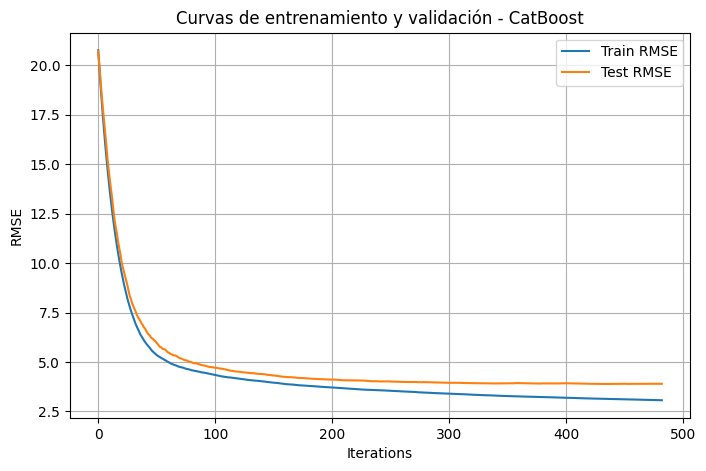

In [29]:
evals_result = cat_model.get_evals_result()

train_rmse = evals_result['learn']['RMSE']
test_rmse  = evals_result['validation']['RMSE']
iterations = list(range(len(train_rmse)))


plt.figure(figsize=(8,5))
plt.plot(iterations, train_rmse, label='Train RMSE')
plt.plot(iterations, test_rmse, label='Test RMSE')
plt.xlabel('Iterations')
plt.ylabel('RMSE')
plt.title('Curvas de entrenamiento y validación - CatBoost')
plt.legend()
plt.grid(True)
plt.show()

Observamos que el modelo es estable, y que no generar overfitting.

In [30]:
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test):
    results = {}

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # Función interna: Mean Error
    def mean_error(y_true, y_pred):
        return np.mean(y_pred - y_true)

    # Calcular métricas para cada dataset
    for name, y_true, y_pred in [('Train', y_train, y_train_pred),
                                 ('Validation', y_val, y_val_pred),
                                 ('Test', y_test, y_test_pred)]:
        rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
        me_val = mean_error(y_true, y_pred)
        r2_val = r2_score(y_true, y_pred)

        results[name] = {
            'RMSE': rmse_val,
            'Mean Error': me_val,
            'R2': r2_val
        }

        # Imprimir automáticamente
        print(f"\n{name} Metrics:")
        print(f"RMSE: {rmse_val:.4f}")
        print(f"Mean Error: {me_val:.4f}")
        print(f"R2: {r2_val:.4f}")


    datasets = ['Train', 'Validation', 'Test']
    rmse_values = [results[d]['RMSE'] for d in datasets]
    me_values = [results[d]['Mean Error'] for d in datasets]
    r2_values = [results[d]['R2'] for d in datasets]

    x = np.arange(len(datasets))
    width = 0.25  # ancho de las barras

    plt.figure(figsize=(10,6))
    plt.bar(x - width, rmse_values, width, label='RMSE', color='skyblue')
    plt.bar(x, me_values, width, label='Mean Error', color='orange')
    plt.bar(x + width, r2_values, width, label='R²', color='green')

    plt.xticks(x, datasets)
    plt.ylabel('Valor')
    plt.title('Métricas CatBoost por Dataset')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    return results


Train Metrics:
RMSE: 3.1378
Mean Error: -0.0001
R2: 0.9791

Validation Metrics:
RMSE: 3.8858
Mean Error: 0.0126
R2: 0.9675

Test Metrics:
RMSE: 4.6368
Mean Error: -0.0381
R2: 0.9577


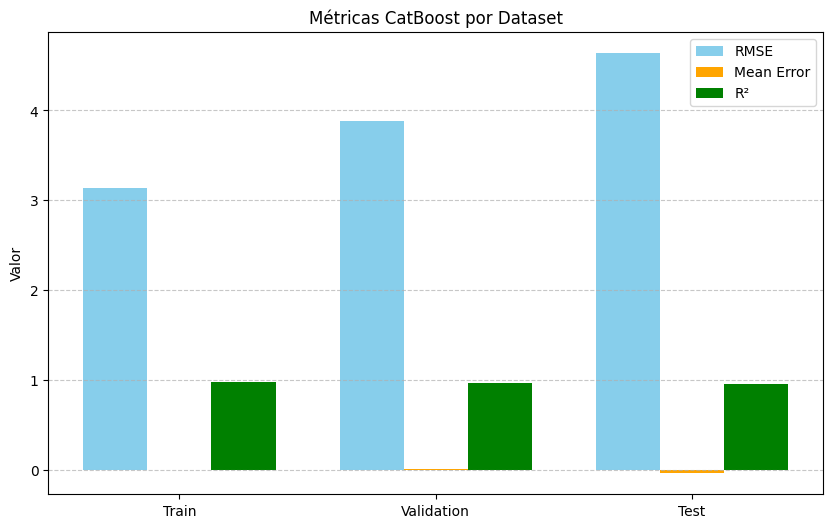

{'Train': {'RMSE': np.float64(3.137751396779465),
  'Mean Error': np.float64(-0.00011397142275291802),
  'R2': 0.9791397337524329},
 'Validation': {'RMSE': np.float64(3.8857540230824483),
  'Mean Error': np.float64(0.01257748351837685),
  'R2': 0.9674790758044495},
 'Test': {'RMSE': np.float64(4.636782559304378),
  'Mean Error': np.float64(-0.03814958001939454),
  'R2': 0.957664084335208}}

In [31]:
evaluate_model(cat_model, X_train, y_train, X_val, y_val, X_test, y_test)

El modelo apprende muy bien y utilizar y generaliza bien, por lo tanto podemos seguir adelante para las prediciones.

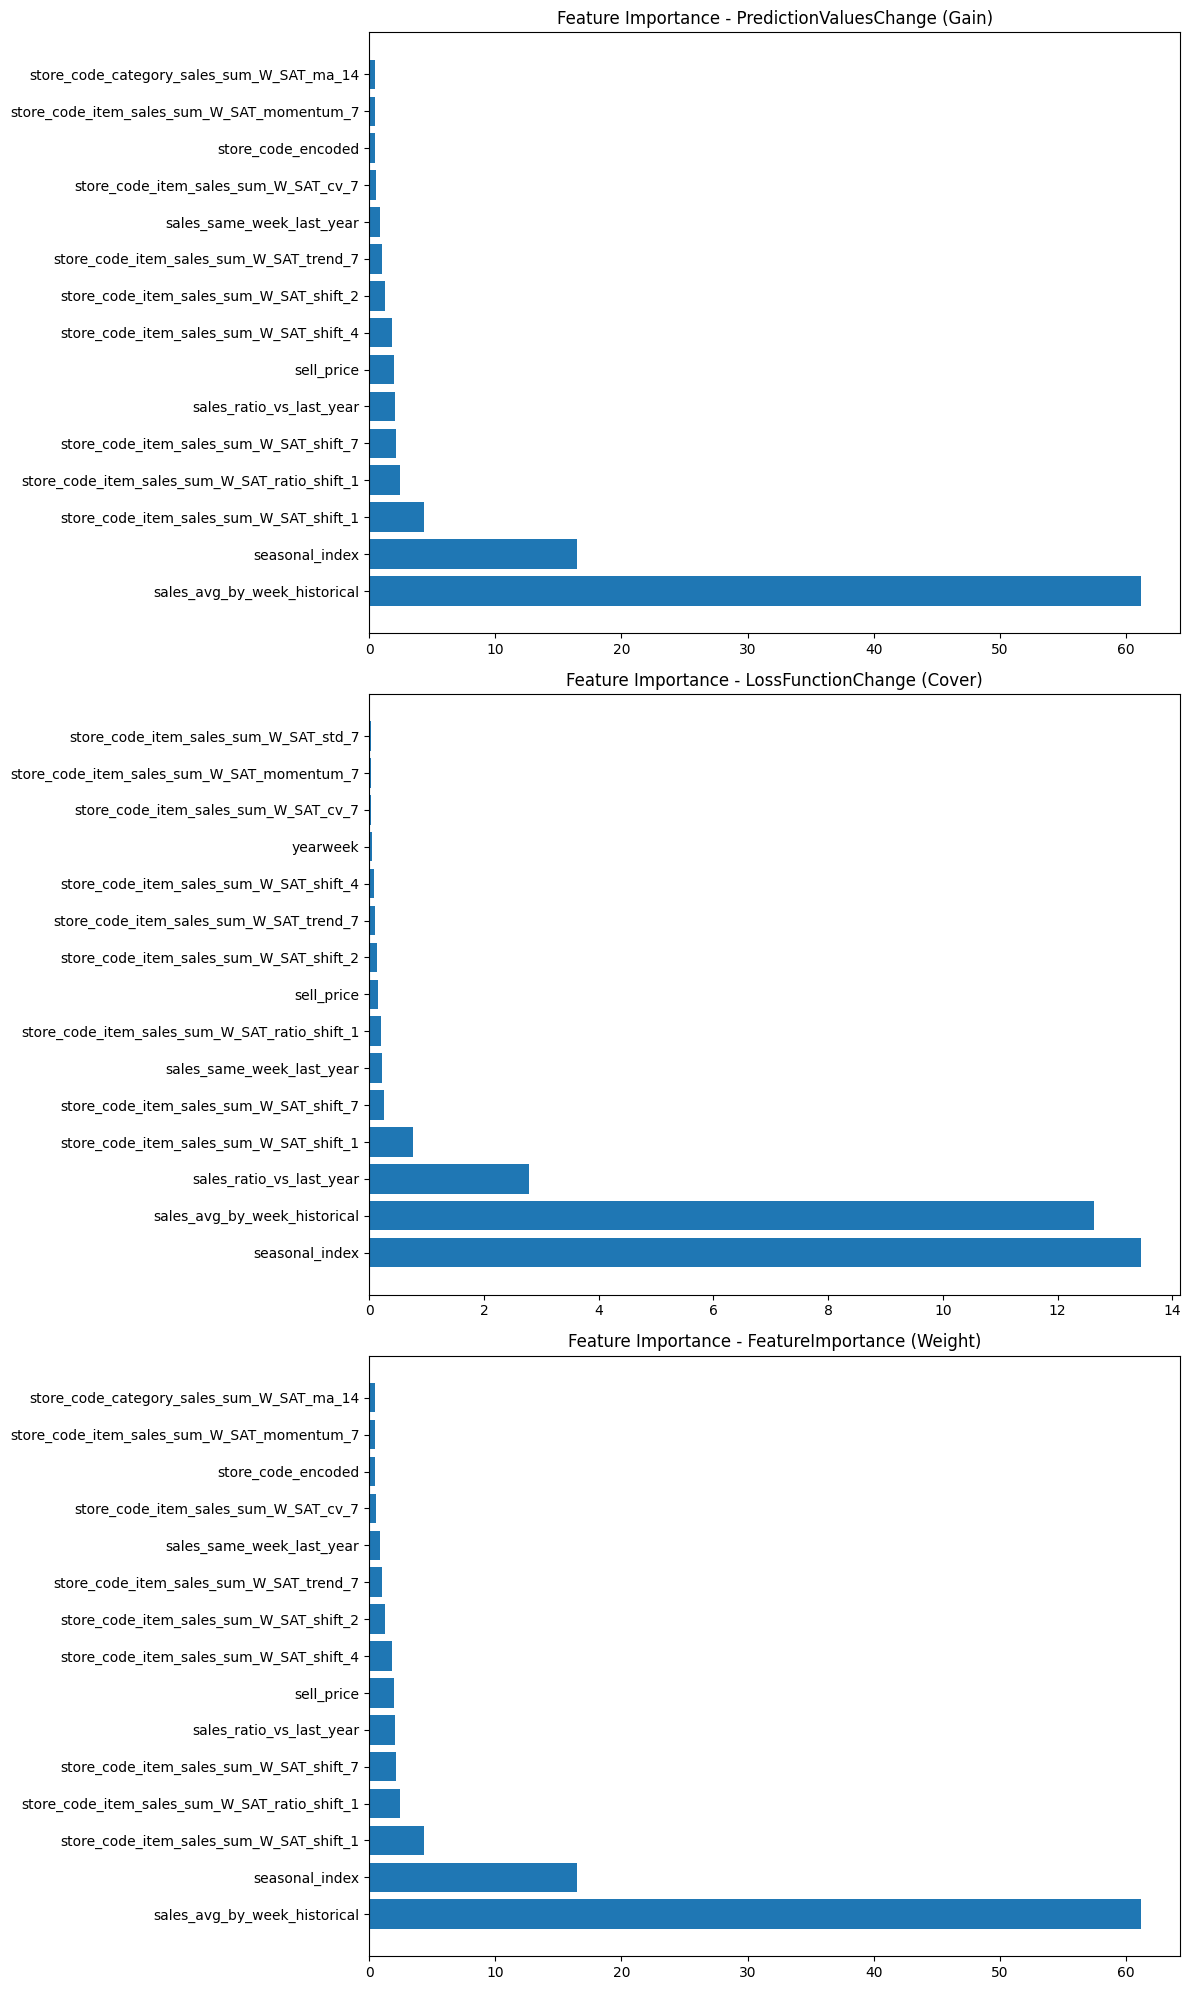

In [32]:

train_pool = Pool(X_train, y_train)

importance_gain = cat_model.get_feature_importance(data=train_pool, type='PredictionValuesChange')
importance_cover = cat_model.get_feature_importance(data=train_pool, type='LossFunctionChange')
importance_weight = cat_model.get_feature_importance(type='FeatureImportance') # 'FeatureImportance' typically doesn't require data

# Obtener nombres de columnas
feature_names = X_train.columns

# Crear DataFrames para graficar
df_gain = pd.DataFrame({"feature": feature_names, "importance": importance_gain}).sort_values(by="importance", ascending=False).head(15)
df_cover = pd.DataFrame({"feature": feature_names, "importance": importance_cover}).sort_values(by="importance", ascending=False).head(15)
df_weight = pd.DataFrame({"feature": feature_names, "importance": importance_weight}).sort_values(by="importance", ascending=False).head(15)

# Graficar
fig, axes = plt.subplots(3, 1, figsize=(12, 20))

# Plotting top 15 features for each type
axes[0].barh(df_gain['feature'], df_gain['importance'])
axes[0].set_title("Feature Importance - PredictionValuesChange (Gain)")

axes[1].barh(df_cover['feature'], df_cover['importance'])
axes[1].set_title("Feature Importance - LossFunctionChange (Cover)")

axes[2].barh(df_weight['feature'], df_weight['importance'])
axes[2].set_title("Feature Importance - FeatureImportance (Weight)")

plt.tight_layout()
plt.show()

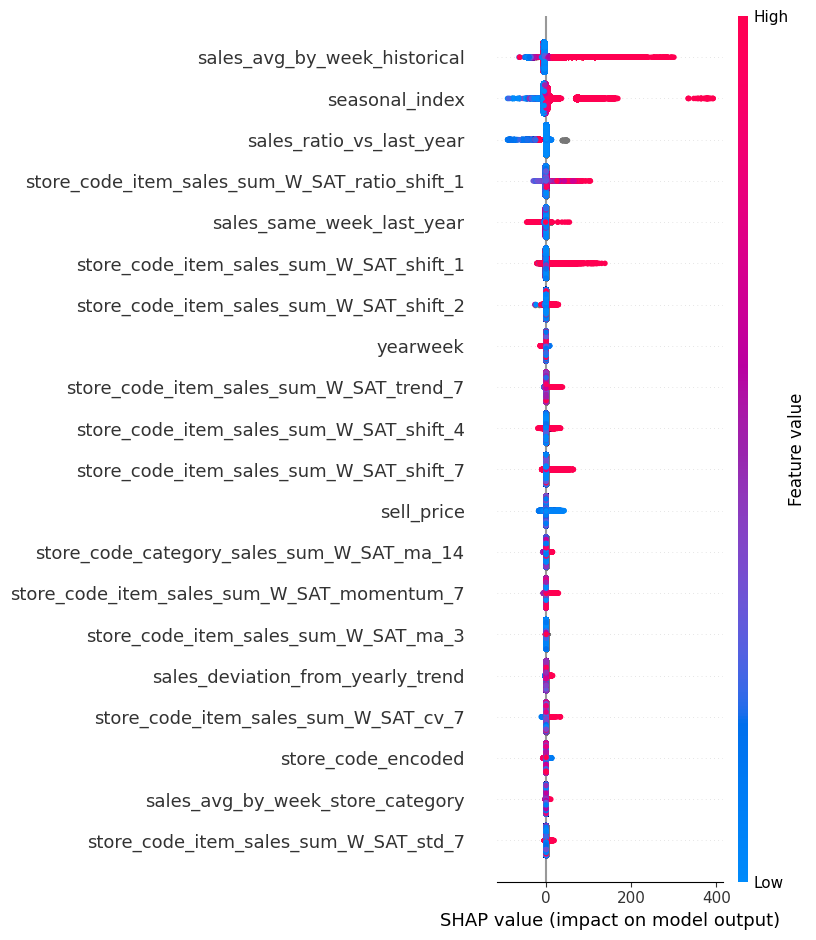

In [39]:
import shap
# Calcula SHAP
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_train)

# Visualiza
shap.summary_plot(shap_values, X_train)

In [37]:
#Importancia promedio absoluta de cada feature
shap_importance = np.abs(shap_values).mean(axis=0)

#Crear DataFrame ordenado
shap_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": shap_importance
}).sort_values(by="importance", ascending=False)

#Top 5 features
top15_features = shap_importance_df.head(15)
print(top15_features)

                                          feature  importance
4                    sales_avg_by_week_historical        7.30
8                                  seasonal_index        6.68
7                        sales_ratio_vs_last_year        1.54
45  store_code_item_sales_sum_W_SAT_ratio_shift_1        0.36
6                       sales_same_week_last_year        0.24
35        store_code_item_sales_sum_W_SAT_shift_1        0.22
36        store_code_item_sales_sum_W_SAT_shift_2        0.17
0                                        yearweek        0.15
42        store_code_item_sales_sum_W_SAT_trend_7        0.12
37        store_code_item_sales_sum_W_SAT_shift_4        0.11
38        store_code_item_sales_sum_W_SAT_shift_7        0.10
1                                      sell_price        0.06
17      store_code_category_sales_sum_W_SAT_ma_14        0.04
46     store_code_item_sales_sum_W_SAT_momentum_7        0.04
39           store_code_item_sales_sum_W_SAT_ma_3        0.03


Predicciones del las ultimas 4 senanas vs datos reales

In [40]:
y_pred = cat_model.predict(X_pred)

In [41]:
df_predictions_detailed = df[df['date'].isin(prediction_dates)].copy()
df_predictions_detailed = df_predictions_detailed.set_index('id_encoded')
df_predictions_detailed['sales'] = pd.Series(y_pred, index=X_pred.index)
df_predictions_detailed = df_predictions_detailed.reset_index()
df_predictions_detailed['revenue'] = df_predictions_detailed['sales'] * df_predictions_detailed['sell_price']

predicciones_df = df_predictions_detailed.copy()
df_pred= pd.DataFrame(predicciones_df.groupby('date')['sales'].sum()).reset_index()

df_pred

,date,sales
0,2016-03-26,"286,508.50"
1,2016-04-02,"313,593.68"
2,2016-04-09,"312,042.66"
3,2016-04-16,"293,255.01"


In [42]:
df_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    4 non-null      datetime64[ns]
 1   sales   4 non-null      float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 196.0 bytes


In [43]:
df_sales_reales =df.groupby('date')['sales'].sum().reset_index()


In [44]:
df_sales_reales[-4:]

,date,sales
105,2016-03-26,282697
106,2016-04-02,309668
107,2016-04-09,306203
108,2016-04-16,286524


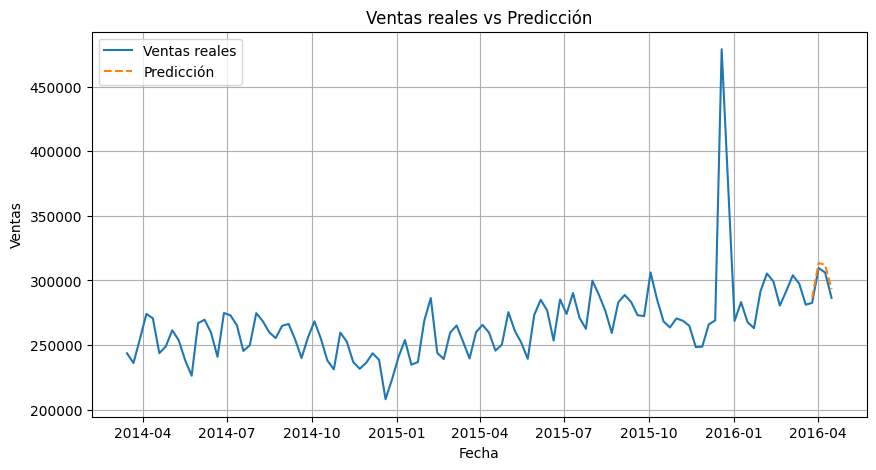

In [45]:
df_sales_reales = df_sales_reales.rename(columns={
    col: col.lower() for col in df_sales_reales.columns
})
df_pred = df_pred.rename(columns={
    col: col.lower() for col in df_pred.columns
})

df_sales_reales = df_sales_reales.rename(columns={"date": "date", "sales": "sales"})
df_pred = df_pred.rename(columns={"fecha": "date", "ventas": "sales"})

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(df_sales_reales["date"], df_sales_reales["sales"], label="Ventas reales")
plt.plot(df_pred["date"], df_pred["sales"], label="Predicción", linestyle="--")


plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Ventas reales vs Predicción")
plt.legend()
plt.grid(True)
plt.show()

observamos que desviacion estandar entre datos reales y predict es inferior a 2%, eso nos permite seguir de forma segura con las predicione.

Creaccion del dataset para precion a 4 semanas adelantes, con las main features y precciones

In [46]:

last_date = df['date'].max()

id_target = df.groupby('id')['sales'].mean()


features = [
    'sales_avg_by_week_historical',
    'seasonal_index',
    'sales_ratio_vs_last_year',
    'store_code_item_sales_sum_W_SAT_ratio_shift_1',
    'store_code_item_sales_sum_W_SAT_shift_1',
    'yearweek',
    'sales_same_week_last_year',
    'store_code_item_sales_sum_W_SAT_trend_7',
    'store_code_item_sales_sum_W_SAT_shift_2',
    'store_code_item_sales_sum_W_SAT_shift_4',
    'store_code_item_sales_sum_W_SAT_shift_7',
    'store_code_category_sales_sum_W_SAT_ma_14',
    'sell_price',
    'store_code_item_sales_sum_W_SAT_ma_3',
    'store_code_item_sales_sum_W_SAT_momentum_7',
    'sales_deviation_from_yearly_trend',
    'store_code_item_sales_sum_W_SAT_cv_7',
    'store_code_item_sales_sum_W_SAT_std_7',
    'store_code_category_revenue_sum_W_SAT_cv_7',
    'store_code_encoded'
]



future_dates = pd.date_range(start=max(df["date"]), periods=4, freq="W-SAT")


def construir_features_para(df, future_dates, X_train_cols, id_target, last_date, X_train_dtypes):

    unique_ids = df['id'].unique()

    future_data_tuples = []
    for f_date in future_dates:
        for u_id in unique_ids:
            future_data_tuples.append((f_date, u_id))
    X_future_full = pd.DataFrame(future_data_tuples, columns=['date', 'id'])

    X_future_full['id_encoded'] = X_future_full['id'].map(id_target)

    last_day_df_static = df[df['date'] == last_date].drop_duplicates(subset=['id']).copy()


    static_per_id_cols = [
        'id', 'item', 'store_code', 'sell_price', 'store_code_encoded', 'item_encoded',
        'region_Boston', 'region_New York', 'region_Philadelphia',
        'category_ACCESORIES', 'category_HOME_&_GARDEN', 'category_SUPERMARKET',
        'event_Easter', 'event_NewYear', 'event_None', 'event_Ramadan starts',
        'event_SuperBowl', 'event_Thanksgiving'
    ]
    static_per_id_cols_present = [col for col in static_per_id_cols if col in last_day_df_static.columns]

    X_future_full = pd.merge(X_future_full, last_day_df_static[static_per_id_cols_present], on='id', how='left')

    X_future_full['yearweek'] = (X_future_full['date'].dt.isocalendar().year.astype(str) +
                                 X_future_full['date'].dt.isocalendar().week.astype(str).str.zfill(2)).astype('int32')
    X_future_full['year'] = X_future_full['date'].dt.isocalendar().year
    X_future_full['week'] = X_future_full['date'].dt.isocalendar().week
    X_future_full['month'] = X_future_full['date'].dt.month
    X_future_full['week_sin'] = np.sin(2 * np.pi * X_future_full['week'] / 52)
    X_future_full['week_cos'] = np.cos(2 * np.pi * X_future_full['week'] / 52)
    X_future_full['month_sin'] = np.sin(2 * np.pi * X_future_full['month'] / 12)
    X_future_full['month_cos'] = np.cos(2 * np.pi * X_future_full['month'] / 12)

    features_to_recalculate = [
        'sales_same_week_last_year', 'sales_ratio_vs_last_year',
        'sales_avg_by_week_historical', 'seasonal_index', 'sales_yearly_trend',
        'sales_deviation_from_yearly_trend'
    ]

    cols_to_exclude_from_propagation = ['id', 'date', 'item', 'store_code', 'id_encoded', 'yearweek', 'year', 'week', 'month',
                                        'week_sin', 'week_cos', 'month_sin', 'month_cos', 'sell_price', 'store_code_encoded', 'item_encoded'] \
                                      + [col for col in X_train_cols if 'region_' in col or 'category_' in col or 'event_' in col]

    features_to_propagate = [col for col in X_train_cols
                             if col not in cols_to_exclude_from_propagation
                             and col not in features_to_recalculate]

    features_to_propagate_existing = [col for col in features_to_propagate if col in df.columns]

    last_known_historical_values_for_merge = df[
        df['date'] == last_date
    ].drop_duplicates(subset=['id'])[features_to_propagate_existing + ['id']].copy()

    X_future_full = pd.merge(
        X_future_full,
        last_known_historical_values_for_merge,
        on='id',
        how='left'
    )


    historical_sales_lookup = df[['date', 'id', 'sales', 'sales_avg_by_week_historical', 'seasonal_index']].copy()
    historical_sales_lookup['date_lagged'] = historical_sales_lookup['date'] + pd.DateOffset(weeks=52)


    historical_sales_lookup_renamed = historical_sales_lookup.rename(columns={
        'sales': 'sales_52_weeks_ago',
        'sales_avg_by_week_historical': 'sales_avg_by_week_historical_52_weeks_ago',
        'seasonal_index': 'seasonal_index_52_weeks_ago'
    })

    X_future_full = pd.merge(
        X_future_full,
        historical_sales_lookup_renamed[['date_lagged', 'id', 'sales_52_weeks_ago', 'sales_avg_by_week_historical_52_weeks_ago', 'seasonal_index_52_weeks_ago']],
        left_on=['date', 'id'],
        right_on=['date_lagged', 'id'],
        how='left'
    )


    X_future_full['sales_same_week_last_year'] = X_future_full['sales_52_weeks_ago'].fillna(0)
    X_future_full['sales_avg_by_week_historical'] = X_future_full['sales_avg_by_week_historical_52_weeks_ago'].fillna(0)
    X_future_full['seasonal_index'] = X_future_full['seasonal_index_52_weeks_ago'].fillna(0)


    X_future_full['sales_ratio_vs_last_year'] = X_future_full['sales_avg_by_week_historical'] / (X_future_full['sales_same_week_last_year'] + 1)
    X_future_full['sales_ratio_vs_last_year'] = X_future_full['sales_ratio_vs_last_year'].replace([np.inf, -np.inf], np.nan).fillna(0) # Handle division by zero



    last_known_trends = df[
        df['date'] == last_date
    ].drop_duplicates(subset=['id'])[['id', 'sales_yearly_trend', 'sales_deviation_from_yearly_trend']].copy()


    last_known_trends_renamed = last_known_trends.rename(columns={
        'sales_yearly_trend': 'sales_yearly_trend_last_known',
        'sales_deviation_from_yearly_trend': 'sales_deviation_from_yearly_trend_last_known'
    })

    X_future_full = pd.merge(
        X_future_full,
        last_known_trends_renamed[['id', 'sales_yearly_trend_last_known', 'sales_deviation_from_yearly_trend_last_known']],
        on='id',
        how='left'
    )
    X_future_full['sales_yearly_trend'] = X_future_full['sales_yearly_trend_last_known'].fillna(0)
    X_future_full['sales_deviation_from_yearly_trend'] = X_future_full['sales_deviation_from_yearly_trend_last_known'].fillna(0)

    X_future_full.drop(columns=[
        'date_lagged',
        'sales_52_weeks_ago',
        'sales_avg_by_week_historical_52_weeks_ago',
        'seasonal_index_52_weeks_ago',
        'sales_yearly_trend_last_known',
        'sales_deviation_from_yearly_trend_last_known'
    ], errors='ignore', inplace=True)


    missing_cols = set(X_train_cols) - set(X_future_full.columns)
    for col in missing_cols:
        X_future_full[col] = 0


    for col in X_train_cols:
        if col in X_future_full.columns and pd.api.types.is_numeric_dtype(X_future_full[col]):
            X_future_full[col] = X_future_full[col].fillna(0)


    df_future_mapping = X_future_full[['date', 'id_encoded', 'id', 'item', 'store_code', 'sell_price']].copy()


    X_future = X_future_full.set_index('id_encoded')
    X_future = X_future[X_train_cols].copy()


    for col in X_train_cols:
        if col in X_future.columns:
            expected_dtype = X_train_dtypes[col]
            if expected_dtype == 'bool':
                X_future[col] = X_future[col].astype(bool)
            elif 'float' in str(expected_dtype):
                X_future[col] = X_future[col].astype(float)
                X_future[col] = X_future[col].astype(expected_dtype)
            elif 'int' in str(expected_dtype):

                try:
                    X_future[col] = X_future[col].astype(float).fillna(0).astype(expected_dtype)
                except TypeError:
                    X_future[col] = X_future[col].fillna(0).astype(expected_dtype)

    return X_future, df_future_mapping



last_date = df['date'].max()
X_future, df_future_mapping = construir_features_para(df=df, future_dates=future_dates, X_train_cols=X_train.columns, id_target=id_target, last_date=last_date, X_train_dtypes=X_train.dtypes)



y_future = cat_model.predict(X_future)
y_future_clipped = np.clip(y_future, 0, df['sales'].max() * 1.2)

#
df_future_predictions_detailed = df_future_mapping.copy()
df_future_predictions_detailed['sales'] = y_future_clipped
df_future_predictions_detailed['revenue'] = df_future_predictions_detailed['sales'] * df_future_predictions_detailed['sell_price']


df_pred_fut = df_future_predictions_detailed.groupby('date')['sales'].sum().reset_index()
df_pred_fut.rename(columns={'sales': 'sales_pred'}, inplace=True)

print(df_pred_fut)


        date  sales_pred
0 2016-04-16  291,980.60
1 2016-04-23  295,534.12
2 2016-04-30  316,421.39
3 2016-05-07  304,883.73


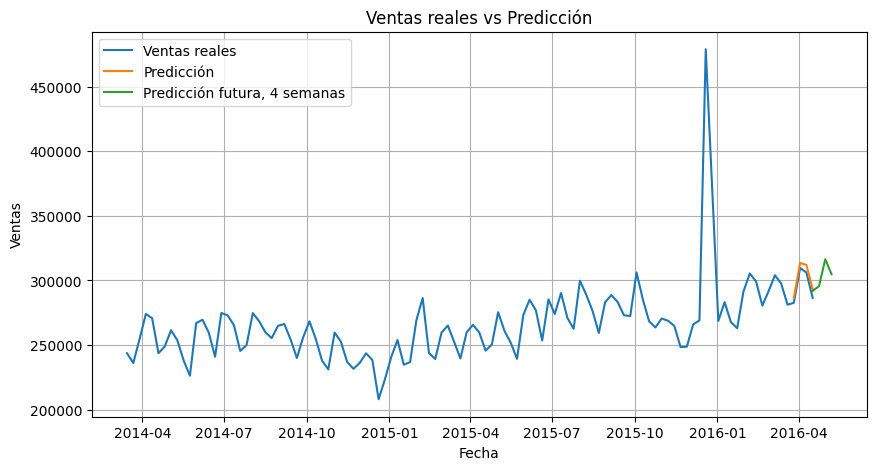

In [47]:
df_sales_reales = df_sales_reales.rename(columns={
    col: col.lower() for col in df_sales_reales.columns
})
df_pred = df_pred.rename(columns={
    col: col.lower() for col in df_pred.columns
})
df_sales_reales = df_sales_reales.rename(columns={
    col: col.lower() for col in df_sales_reales.columns
})
df_pred_fut = df_pred_fut.rename(columns={
    col: col.lower() for col in df_pred.columns
})

df_sales_reales = df_sales_reales.rename(columns={"date": "date", "sales": "sales"})
df_pred = df_pred.rename(columns={"fecha": "date", "ventas": "sales"})
df_pred_fut = df_pred_fut.rename(columns={"date": "date", "sales_pred": "sales_pred"})

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(df_sales_reales["date"], df_sales_reales["sales"], label="Ventas reales")
plt.plot(df_pred["date"], df_pred["sales"], label="Predicción")
plt.plot(df_pred_fut["date"], df_pred_fut["sales_pred"], label="Predicción futura, 4 semanas")


plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Ventas reales vs Predicción")
plt.legend()
plt.grid(True)
plt.show()



El modelo ajusta bien los datos de predicciones a 4 semanas y marcar tendencia similares a las semanas anteriores.